Name: Prajakta Mahangare

Roll No: 34

PRN NO.: 12520047

Class: CSE(AI)-SEDA Batch: B2

Assignment No.6 Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following: a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis b. Bivariate analysis: Linear and logistic regression modeling c. Multiple Regression analysis d. Also compare the results of the above analysis for the two data sets.

Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from scipy.stats import skew, kurtosis
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report

Load Datasets

In [ ]:
df_pima = pd.read_csv("diabetes.csv")
print("Pima Dataset Shape:", df_pima.shape)
df_pima.head()

Pima Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes = load_diabetes()
df_uci = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df_uci['target'] = diabetes.target
print("UCI Dataset Shape:", df_uci.shape)
df_uci.head()

UCI Dataset Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Data CLeaning

In [ ]:
print("Pima Missing Values:\n", df_pima.isnull().sum())
print("UCI Missing Values:\n", df_uci.isnull().sum())

Pima Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
UCI Missing Values:
 age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


Replace Invalid Zeros (Pima Dataset)

In [ ]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df_pima[cols] = df_pima[cols].replace(0, np.nan)

df_pima.fillna(df_pima.mean(), inplace=True)
df_pima.drop_duplicates(inplace=True)

Univariate Analysis

Frequency

In [ ]:
print("Pima Outcome Frequency:\n", df_pima['Outcome'].value_counts())
print("\nUCI Target Frequency (Top 10):\n", df_uci['target'].value_counts().head(10))

Pima Outcome Frequency:
 Outcome
0    500
1    268
Name: count, dtype: int64

UCI Target Frequency (Top 10):
 target
200.0    6
72.0     6
178.0    5
71.0     5
90.0     5
97.0     4
55.0     4
53.0     4
131.0    4
150.0    4
Name: count, dtype: int64


Mean, Median, Mode

In [ ]:
print("Pima Mean:\n", df_pima.mean())
print("UCI Mean:\n", df_uci.mean())

print("Pima Median:\n", df_pima.median())
print("UCI Median:\n", df_uci.median())

print("Pima Mode:\n", df_pima.mode().iloc[0])
print("UCI Mode:\n", df_uci.mode().iloc[0])

Pima Mean:
 Pregnancies                   3.845052
Glucose                     121.686763
BloodPressure                72.405184
SkinThickness                29.153420
Insulin                     155.548223
BMI                          32.457464
DiabetesPedigreeFunction      0.471876
Age                          33.240885
Outcome                       0.348958
dtype: float64
UCI Mean:
 age      -1.444295e-18
sex       2.543215e-18
bmi      -2.255925e-16
bp       -4.854086e-17
s1       -1.428596e-17
s2        3.898811e-17
s3       -6.028360e-18
s4       -1.788100e-17
s5        9.243486e-17
s6        1.351770e-17
target    1.521335e+02
dtype: float64
Pima Median:
 Pregnancies                   3.000000
Glucose                     117.000000
BloodPressure                72.202592
SkinThickness                29.153420
Insulin                     155.548223
BMI                          32.400000
DiabetesPedigreeFunction      0.372500
Age                          29.000000
Outcome          

Variance & Standard Deviation

In [ ]:
print("Pima Variance:\n", df_pima.var())
print("UCI Variance:\n", df_uci.var())

print("Pima Std Dev:\n", df_pima.std())
print("UCI Std Dev:\n", df_uci.std())

Pima Variance:
 Pregnancies                   11.354056
Glucose                      926.346983
BloodPressure                146.321591
SkinThickness                 77.280660
Insulin                     7228.588766
BMI                           47.267706
DiabetesPedigreeFunction       0.109779
Age                          138.303046
Outcome                        0.227483
dtype: float64
UCI Variance:
 age          0.002268
sex          0.002268
bmi          0.002268
bp           0.002268
s1           0.002268
s2           0.002268
s3           0.002268
s4           0.002268
s5           0.002268
s6           0.002268
target    5943.331348
dtype: float64
Pima Std Dev:
 Pregnancies                  3.369578
Glucose                     30.435949
BloodPressure               12.096346
SkinThickness                8.790942
Insulin                     85.021108
BMI                          6.875151
DiabetesPedigreeFunction     0.331329
Age                         11.760232
Outcome           

Skewness & Kurtosis

In [ ]:
print("PIMA SKEWNESS & KURTOSIS")
for col in df_pima.columns:
    print(col, "Skew:", skew(df_pima[col]), "Kurtosis:", kurtosis(df_pima[col]))

print("\nUCI SKEWNESS & KURTOSIS")
for col in df_uci.columns:
    print(col, "Skew:", skew(df_uci[col]), "Kurtosis:", kurtosis(df_uci[col]))

PIMA SKEWNESS & KURTOSIS
Pregnancies Skew: 0.8999119408414357 Kurtosis: 0.15038273760948462
Glucose Skew: 0.531677628850459 Kurtosis: -0.2652767871408801
BloodPressure Skew: 0.1370370472689305 Kurtosis: 1.082847367848931
SkinThickness Skew: 0.8205664594675018 Kurtosis: 5.3718544792635345
Insulin Skew: 3.013183811523944 Kurtosis: 15.078748264774752
BMI Skew: 0.5970835583878779 Kurtosis: 0.9057125569396862
DiabetesPedigreeFunction Skew: 1.9161592037386292 Kurtosis: 5.550792047551203
Age Skew: 1.127389259531697 Kurtosis: 0.6311769413798585
Outcome Skew: 0.6337757030614577 Kurtosis: -1.5983283582089547

UCI SKEWNESS & KURTOSIS
age Skew: -0.23059556012398927 Kurtosis: -0.6771986900987508
sex Skew: 0.1269518188640044 Kurtosis: -1.983883235687121
bmi Skew: 0.5961166556214368 Kurtosis: 0.08047812866813064
bp Skew: 0.28967103827590446 Kurtosis: -0.5403332293804954
s1 Skew: 0.3768238227280956 Kurtosis: 0.2167770625244283
s2 Skew: 0.4351087583570202 Kurtosis: 0.5810556912433786
s3 Skew: 0.7965401

VISUALIZATION

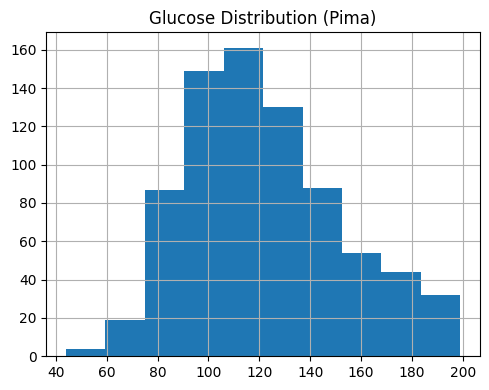

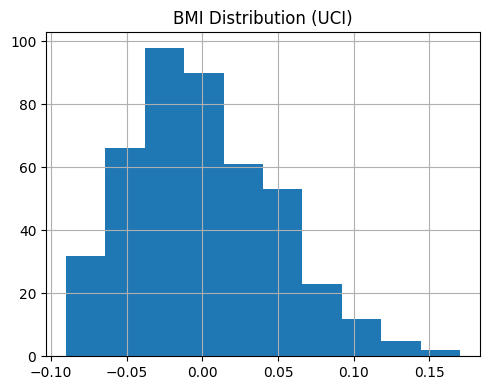

In [ ]:
plt.figure(figsize=(5,4))
df_pima['Glucose'].hist()
plt.title("Glucose Distribution (Pima)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
df_uci['bmi'].hist()
plt.title("BMI Distribution (UCI)")
plt.tight_layout()
plt.show()

Correlation Heatmap

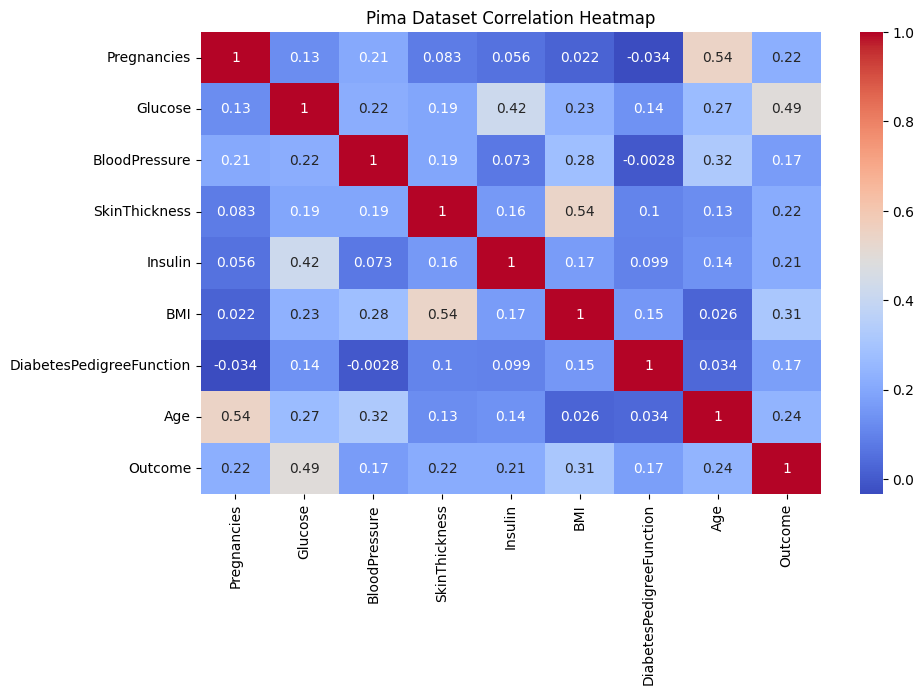

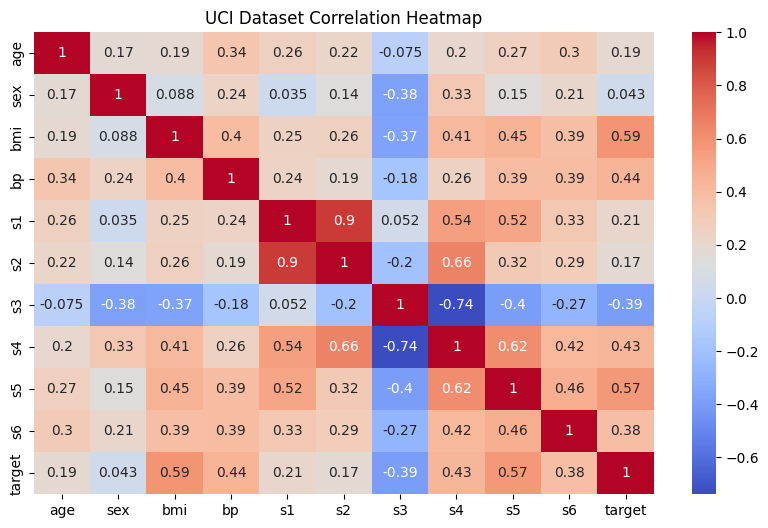

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df_pima.corr(), annot=True, cmap='coolwarm')
plt.title("Pima Dataset Correlation Heatmap")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df_uci.corr(), annot=True, cmap='coolwarm')
plt.title("UCI Dataset Correlation Heatmap")
plt.show()

Bivariate Analysis

Linear Regression(UCI Dataset)

In [ ]:
X_uci = df_uci.drop('target', axis=1)
y_uci = df_uci['target']

X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_uci, y_uci, test_size=0.2, random_state=42)

lin_model = LinearRegression()
lin_model.fit(X_train_u, y_train_u)

y_pred_u = lin_model.predict(X_test_u)

print("UCI Linear Regression")
print("MSE:", mean_squared_error(y_test_u, y_pred_u))
print("R2 Score:", r2_score(y_test_u, y_pred_u))

UCI Linear Regression
MSE: 2900.193628493482
R2 Score: 0.4526027629719195


Logistic Regression (Pima Dataset)

In [ ]:
X_pima = df_pima.drop('Outcome', axis=1)
y_pima = df_pima['Outcome']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pima, y_pima, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train_p, y_train_p)

y_pred_p = log_model.predict(X_test_p)

print("Pima Logistic Regression")
print("Accuracy:", accuracy_score(y_test_p, y_pred_p))

Pima Logistic Regression
Accuracy: 0.7532467532467533


MULTIPLE REGRESSION ANALYSIS(UCI)

In [ ]:
multi_model = LinearRegression()
multi_model.fit(X_train_u, y_train_u)

print("Multiple Regression R2 Score:",
      multi_model.score(X_test_u, y_test_u))

Multiple Regression R2 Score: 0.4526027629719195


Confusion Matrix

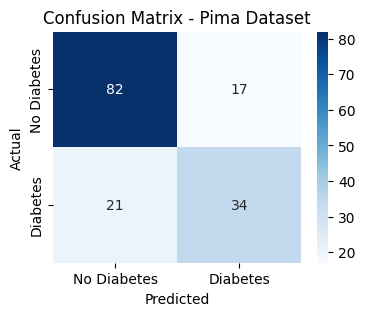

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_p, y_pred_p)

plt.figure(figsize=(4,3))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])

plt.title("Confusion Matrix - Pima Dataset")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Precision, Recall, F1

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

print("Precision:", precision_score(y_test_p, y_pred_p))
print("Recall:", recall_score(y_test_p, y_pred_p))
print("F1 Score:", f1_score(y_test_p, y_pred_p))

print("\nClassification Report:\n",
      classification_report(y_test_p, y_pred_p))

Precision: 0.6666666666666666
Recall: 0.6181818181818182
F1 Score: 0.6415094339622641

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



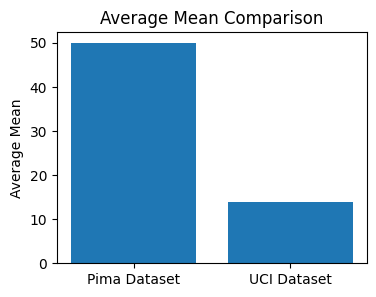

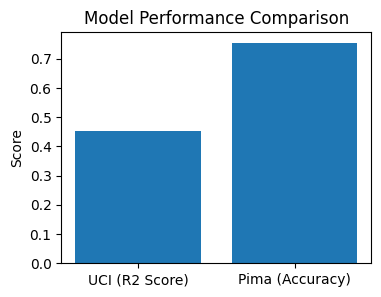

In [ ]:
pima_mean = df_pima.mean().mean()
uci_mean = df_uci.mean().mean()

plt.figure(figsize=(4,3))
plt.bar(['Pima Dataset','UCI Dataset'],
        [pima_mean, uci_mean])
plt.title("Average Mean Comparison")
plt.ylabel("Average Mean")
plt.show()

uci_r2 = r2_score(y_test_u, y_pred_u)
pima_accuracy = accuracy_score(y_test_p, y_pred_p)

plt.figure(figsize=(4,3))
plt.bar(['UCI (R2 Score)','Pima (Accuracy)'],
        [uci_r2, pima_accuracy])
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

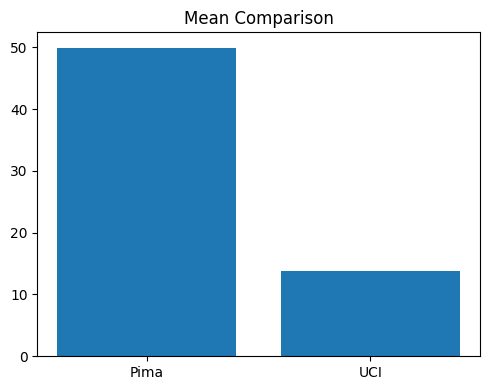

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(['Pima','UCI'], [pima_mean, uci_mean])
plt.title("Mean Comparison")
plt.tight_layout()
plt.show()